# Benchmark Random Forest : Naïve vs Cython+joblib vs Sklearn

Compare les temps d'entraînement de 3 implémentations sur 4 datasets, avec variation du nombre d'arbres.

| Version | Description |
|---|---|
| **Naive** | Python pur, listes, séquentiel |
| **Cython+joblib** | Calculs compilés en C + arbres en parallèle  |
| **Sklearn** | Référence industrielle |

**Datasets :** Moons (classif), Breast Cancer (classif), Sinus bruité (regress), California Housing (regress)  
**Paramètres :** `N_RUNS=10`, `TREES_LIST=[50, 100, 150]`, `DEPTH=5`

In [39]:
# 1. Compilation Cython
import subprocess, sys, os, warnings
warnings.filterwarnings('ignore')
os.chdir(os.path.dirname(os.path.abspath('__file__')))
sys.path.insert(0, '.')
result = subprocess.run(
    [sys.executable, 'setup.py', 'build_ext', '--inplace'],
    capture_output=True, text=True
)

In [40]:
# 2. Imports + configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.datasets import load_breast_cancer, fetch_california_housing, make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, r2_score
from naive import RandomForestClassifieurNaif, RandomForestRegresseurNaif
from optimised_cython import RandomForestClassifieurCython, RandomForestRegresseurCython

N_RUNS     = 10
TREES_LIST = [50, 100, 150]
DEPTH      = 5
GRAINE     = 42
COULEURS   = {'Naive': '#e74c3c', 'Cython+joblib': '#e67e22', 'Sklearn': '#9b59b6'}
print(f'Config : {N_RUNS} runs , arbres={TREES_LIST} , profondeur {DEPTH}')

Config : 10 runs , arbres=[50, 100, 150] , profondeur 5


In [41]:
# 3. Chargement des datasets
rng = np.random.RandomState(GRAINE)

X_m, y_m = make_moons(n_samples=600, noise=0.25, random_state=GRAINE)
X_m = X_m.astype(np.float64); y_m = y_m.astype(np.int64)
Xtr_m, Xte_m, ytr_m, yte_m = train_test_split(X_m, y_m, test_size=0.25, random_state=GRAINE, stratify=y_m)

bc = load_breast_cancer()
X_bc = bc.data.astype(np.float64); y_bc = bc.target.astype(np.int64)
Xtr_bc, Xte_bc, ytr_bc, yte_bc = train_test_split(X_bc, y_bc, test_size=0.25, random_state=GRAINE, stratify=y_bc)

X_sin = np.sort(rng.uniform(0, 6, 400))[:, None].astype(np.float64)
y_sin = (np.sin(X_sin.ravel()) + rng.normal(0, 0.3, 400)).astype(np.float64)
Xtr_s, Xte_s, ytr_s, yte_s = train_test_split(X_sin, y_sin, test_size=0.25, random_state=GRAINE)

cal = fetch_california_housing()
idx = rng.choice(len(cal.target), 2000, replace=False)
X_cal = cal.data[idx].astype(np.float64); y_cal = cal.target[idx].astype(np.float64)
Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(X_cal, y_cal, test_size=0.25, random_state=GRAINE)

print('4 datasets charges.')

4 datasets charges.


In [42]:
# 4. Fonction benchmark + definition des datasets
def run_benchmark(nom, modele_fn, X_train, y_train, X_test, n_runs=N_RUNS, as_list=False):
    Xtr = X_train.tolist() if as_list else X_train
    ytr = y_train.tolist() if as_list else y_train
    Xte = X_test.tolist()  if as_list else X_test
    temps = []
    modele = None
    for _ in range(n_runs):
        modele = modele_fn()
        t0 = time.perf_counter()
        modele.fit(Xtr, ytr)
        temps.append(time.perf_counter() - t0)
    preds = np.array(modele.predict(Xte))
    return {'nom': nom, 'temps': temps, 'preds': preds,
            'moy': float(np.mean(temps)), 'std': float(np.std(temps))}


DATASETS = [
    ('Moons (classif)',         Xtr_m,  ytr_m,  Xte_m,  yte_m,  'classif'),
    ('Breast Cancer (classif)', Xtr_bc, ytr_bc, Xte_bc, yte_bc, 'classif'),
    ('Sinus (regress)',         Xtr_s,  ytr_s,  Xte_s,  yte_s,  'regress'),
    ('California (regress)',    Xtr_c,  ytr_c,  Xte_c,  yte_c,  'regress'),
]

In [43]:
# 5. Execution : N_RUNS=10, arbres=[50, 100, 150]
tous_resultats = {}

for n_trees in TREES_LIST:
    kw    = {'n_arbres': n_trees, 'profondeur_max': DEPTH, 'graine': GRAINE}
    kw_sk = {'n_estimators': n_trees, 'max_depth': DEPTH, 'random_state': GRAINE, 'n_jobs': 1}
    print(f'\n====== {n_trees} arbres ======')
    resultats_nt = {}
    for titre, Xtr, ytr, Xte, yte, tache in DATASETS:
        print(f'  {titre}')
        if tache == 'classif':
            impls = [
                ('Naive',         lambda: RandomForestClassifieurNaif(**kw),   True),
                ('Cython+joblib', lambda: RandomForestClassifieurCython(**kw), False),
                ('Sklearn',       lambda: RandomForestClassifier(**kw_sk),     False),
            ]
        else:
            impls = [
                ('Naive',         lambda: RandomForestRegresseurNaif(**kw),   True),
                ('Cython+joblib', lambda: RandomForestRegresseurCython(**kw), False),
                ('Sklearn',       lambda: RandomForestRegressor(**kw_sk),     False),
            ]
        res_list = []
        for nom, fn, as_list in impls:
            r = run_benchmark(nom, fn, Xtr, ytr, Xte, as_list=as_list)
            r['metric']      = accuracy_score(yte, r['preds']) if tache == 'classif' else r2_score(yte, r['preds'])
            r['metric_name'] = 'Accuracy' if tache == 'classif' else 'R2'
            print(f"    {nom:<15} {r['moy']:.4f}s +/- {r['std']:.4f}s | {r['metric_name']}={r['metric']:.3f}")
            res_list.append(r)
        resultats_nt[titre] = res_list
    tous_resultats[n_trees] = resultats_nt


====== 50 arbres ======
  Moons (classif)
    Naive           1.4062s +/- 0.0355s | Accuracy=0.900
    Cython+joblib   0.0961s +/- 0.1382s | Accuracy=0.900
    Sklearn         0.0260s +/- 0.0005s | Accuracy=0.913
  Breast Cancer (classif)
    Naive           6.8361s +/- 0.0434s | Accuracy=0.951
    Cython+joblib   0.1747s +/- 0.0106s | Accuracy=0.944
    Sklearn         0.0391s +/- 0.0021s | Accuracy=0.951
  Sinus (regress)
    Naive           0.9066s +/- 0.0058s | R2=0.835
    Cython+joblib   0.0440s +/- 0.0160s | R2=0.831
    Sklearn         0.0204s +/- 0.0003s | R2=0.842
  California (regress)
    Naive           37.5164s +/- 0.1543s | R2=0.647
    Cython+joblib   0.2958s +/- 0.0727s | R2=0.628
    Sklearn         0.1048s +/- 0.0005s | R2=0.659

====== 100 arbres ======
  Moons (classif)
    Naive           2.7416s +/- 0.0121s | Accuracy=0.907
    Cython+joblib   0.0820s +/- 0.0051s | Accuracy=0.907
    Sklearn         0.0521s +/- 0.0019s | Accuracy=0.920
  Breast Cancer (classif)


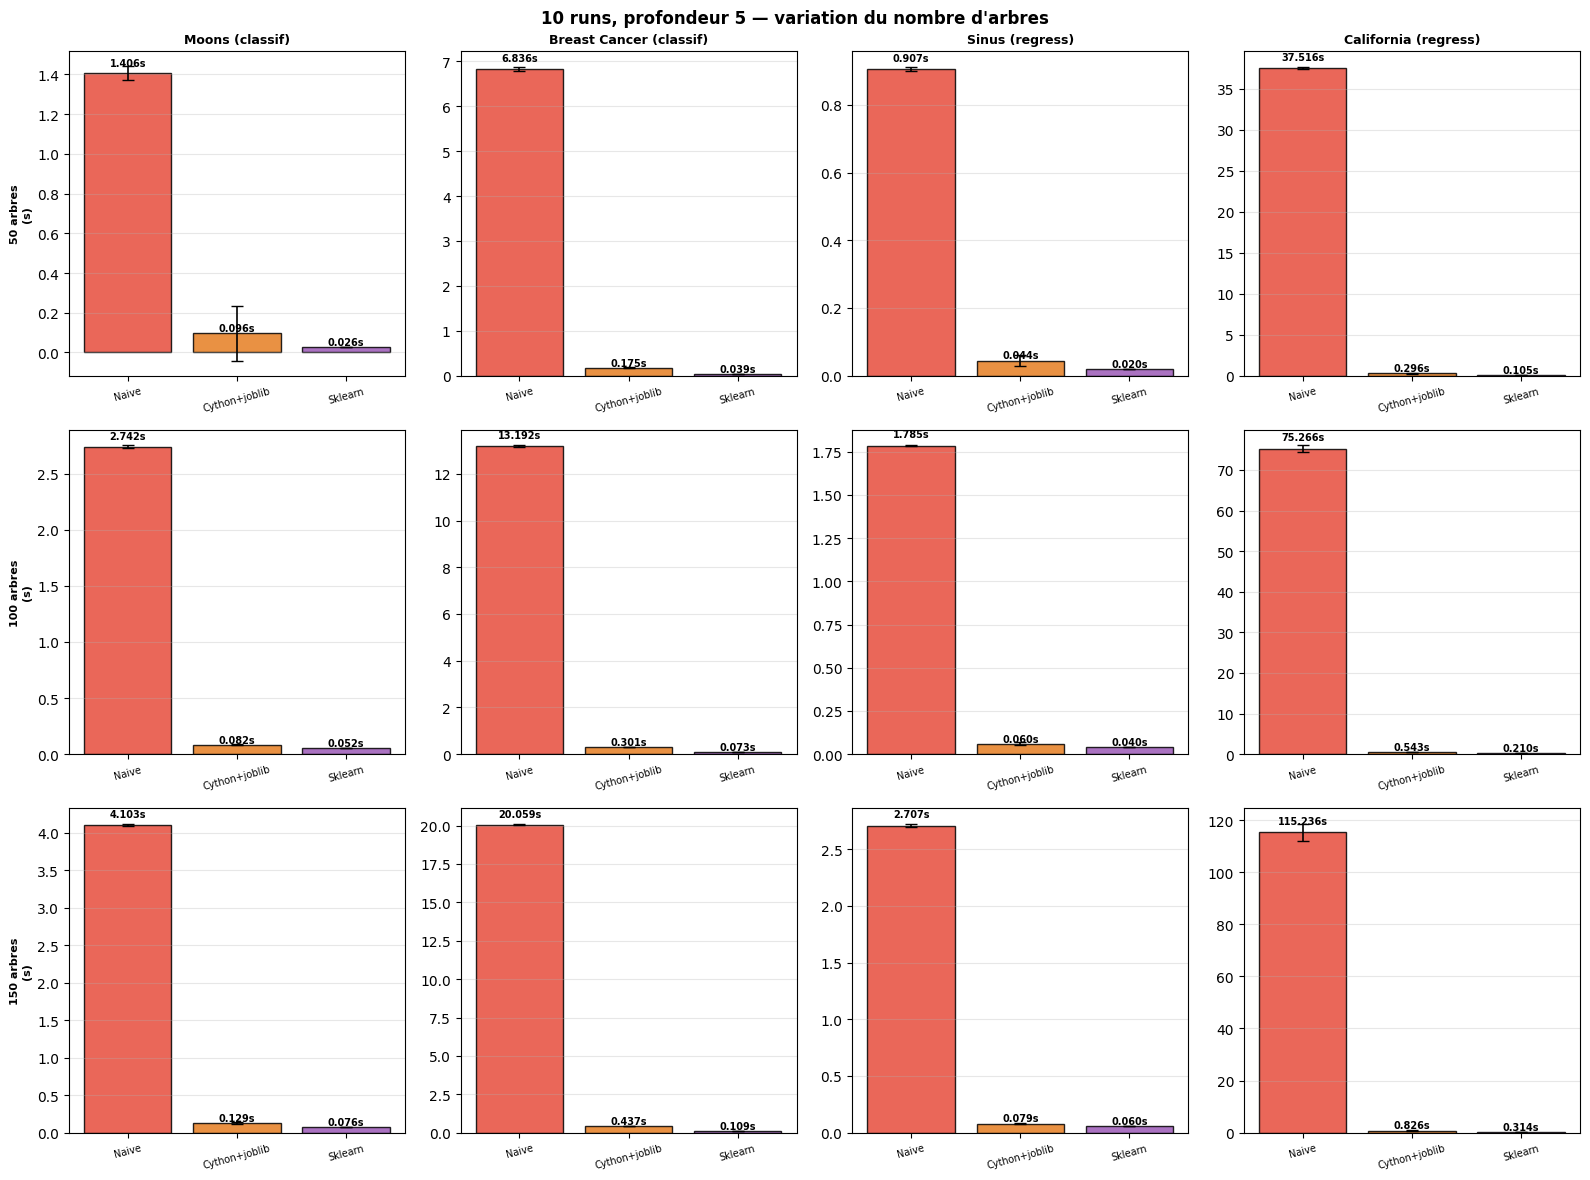

In [44]:
# 6. Histogrammes : grille 3 lignes (nb arbres) x 4 colonnes (datasets)
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle(f"{N_RUNS} runs, profondeur {DEPTH} — variation du nombre d'arbres",
             fontsize=12, fontweight='bold')

for i, n_trees in enumerate(TREES_LIST):
    for j, (titre, res) in enumerate(tous_resultats[n_trees].items()):
        ax = axes[i, j]
        noms = [r['nom'] for r in res]
        moys = [r['moy'] for r in res]
        stds = [r['std'] for r in res]
        bars = ax.bar(noms, moys, color=[COULEURS[n] for n in noms],
                      edgecolor='black', alpha=0.85)
        ax.errorbar(noms, moys, yerr=stds, fmt='none', color='black', capsize=4, lw=1.2)
        for bar, v in zip(bars, moys):
            ax.text(bar.get_x() + bar.get_width() / 2, v * 1.02,
                    f'{v:.3f}s', ha='center', va='bottom', fontsize=7, fontweight='bold')
        if i == 0:
            ax.set_title(titre, fontweight='bold', fontsize=9)
        if j == 0:
            ax.set_ylabel(f'{n_trees} arbres\n(s)', fontweight='bold', fontsize=8)
        ax.tick_params(axis='x', rotation=15, labelsize=7)
        ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('benchmark_temps.png', dpi=150, bbox_inches='tight')
plt.show()

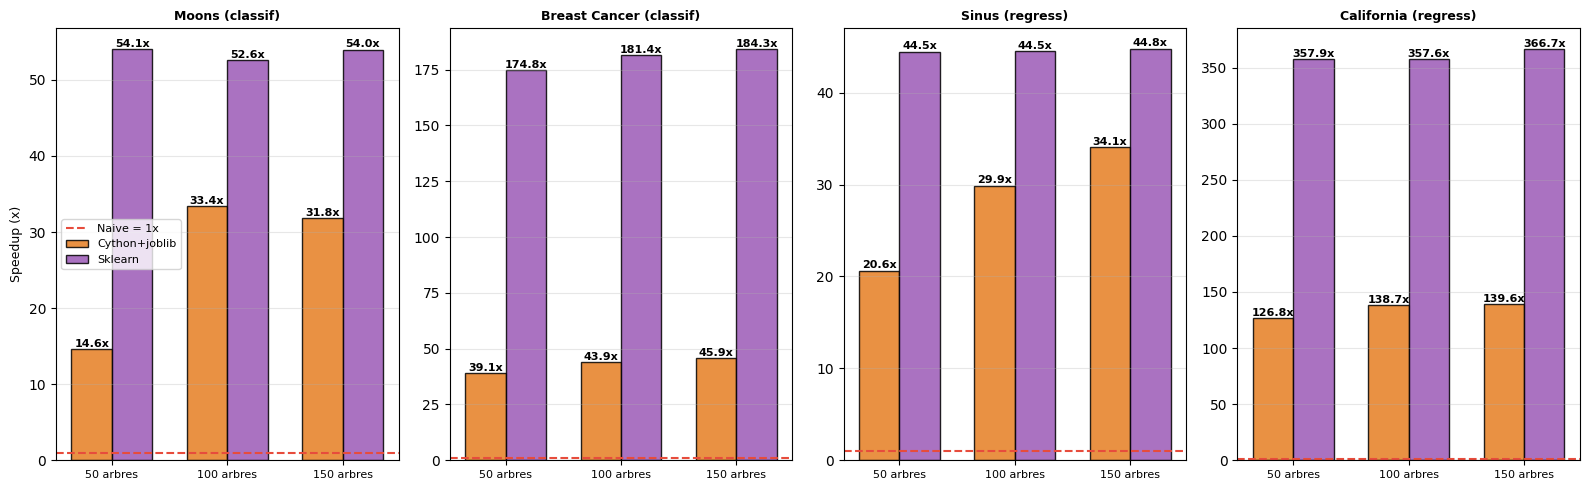

In [46]:
# 8. Speedup vs Naive
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
# fig.suptitle("Speedup vs Naive — variation du nombre d'arbres",
#              fontsize=12, fontweight='bold')

impls_sp  = ['Cython+joblib', 'Sklearn']
couleurs_sp = {'Cython+joblib': '#e67e22', 'Sklearn': '#9b59b6'}
x     = np.arange(len(TREES_LIST))
width = 0.35

for j, titre in enumerate(tous_resultats[TREES_LIST[0]]):
    ax = axes[j]
    for k, impl in enumerate(impls_sp):
        speedups = []
        for n_trees in TREES_LIST:
            res     = tous_resultats[n_trees][titre]
            t_naive = next(r['moy'] for r in res if r['nom'] == 'Naive')
            t_impl  = next(r['moy'] for r in res if r['nom'] == impl)
            speedups.append(t_naive / t_impl)
        offset = (k - 0.5) * width
        bars = ax.bar(x + offset, speedups, width, label=impl,
                      color=couleurs_sp[impl], edgecolor='black', alpha=0.85)
        for bar, v in zip(bars, speedups):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                    f'{v:.1f}x', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.axhline(1, color='#e74c3c', linestyle='--', lw=1.5, label='Naive = 1x')
    ax.set_title(titre, fontweight='bold', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{n} arbres' for n in TREES_LIST], fontsize=8)
    if j == 0:
        ax.set_ylabel('Speedup (x)', fontsize=9)
        ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('speedup_vs_naive.png', dpi=150, bbox_inches='tight')
plt.show()